In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import dist

In [2]:
df_rds = pd.read_csv("../data/raw/_roads.tsv", sep = "\t", low_memory=False)
df_rds.describe()

,lat1,lon1,lat2,lon2,Unnamed: 8,Unnamed: 9,Unnamed: 11,Unnamed: 12,Unnamed: 14,Unnamed: 15,...,Unnamed: 4031,Unnamed: 4032,Unnamed: 4034,Unnamed: 4035,Unnamed: 4037,Unnamed: 4038,Unnamed: 4040,Unnamed: 4041,Unnamed: 4043,Unnamed: 4044
count,877.000000,877.000000,876.000000,876.000000,868.000000,868.000000,852.000000,852.000000,843.000000,843.000000,...,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,23.824894,90.250037,23.830107,90.251002,23.829570,90.252170,23.839467,90.245770,23.835393,90.243829,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
std,1.079927,1.035133,1.081952,1.037238,1.085892,1.035562,1.096923,1.031690,1.090617,1.035085,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,20.862861,88.163583,20.857750,88.076610,20.855333,88.156806,20.847250,88.155139,20.846500,88.155750,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
25%,22.989555,89.383694,22.990784,89.390402,22.990118,89.389812,23.009111,89.396437,23.005667,89.387250,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
50%,23.785611,90.216083,23.788889,90.214903,23.787944,90.207403,23.791194,90.197291,23.790000,90.197333,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
75%,24.613417,90.986944,24.664750,90.991798,24.668701,90.994930,24.671999,90.987152,24.652514,90.987750,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
max,26.488889,92.875666,26.488777,92.730472,26.488750,92.387416,27.786139,92.301250,26.488194,92.300917,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083


In [3]:
df_rds.head()

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
0,N1,LRPS,23.706028,90.443333,LRPSa,23.702917,90.450417,LRPSb,23.702778,90.450472,...,92.29825,LRP466c,20.864667,92.298194,LRP467,20.862972,92.298083,LRPE,20.862917,92.298083
1,N101,LRPS,23.454139,91.212861,LRPSa,23.461889,91.212000,LRP001,23.462944,91.211806,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N102,LRPS,23.478972,91.118194,LRPSa,23.481583,91.116777,LRPSb,23.486666,91.113361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N103,LRPS,23.957028,91.115528,LRP001,23.961917,91.113611,LRP001a,23.967666,91.111889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N104,LRPS,23.009667,91.399416,LRPSa,23.009278,91.395250,LRP001,23.009306,91.389805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_rds.tail()

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
880,Z8910,LRPS,22.674722,90.408889,LRPSa,22.675916,90.412556,LRP001,22.675583,90.417166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
881,Z8913,LRPS,22.396083,90.688666,LRPSa,22.393027,90.688944,LRPSb,22.392666,90.689083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
882,Z8915,LRPS,22.589389,90.619472,LRP001,22.589694,90.623360,LRP001a,22.590027,90.631360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
883,Z8916,LRPS,22.625499,90.661722,LRPSa,22.623888,90.664167,LRP001,22.620305,90.668999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
884,Z8943,LRPS,22.426444,90.849472,LRPSa,22.426416,90.846833,LRP001,22.425444,90.839861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
all_data = []

for rd in df_rds.itertuples(index=False):
    rd_name = rd[0]

    for i in range(1, len(rd)-2, 3):
        lrp = rd[i]
        lat = rd[i+1]
        lon = rd[i+2]

        if pd.isna(lrp) and pd.isna(lat) and pd.isna(lon):
            continue

        all_data.append((rd_name, lrp, lat, lon))

df_all = pd.DataFrame(all_data, columns=["road", "LRP", "LAT", "LON"])

print(df_all)


        road      LRP        LAT        LON
0         N1     LRPS  23.706028  90.443333
1         N1    LRPSa  23.702917  90.450417
2         N1    LRPSb  23.702778  90.450472
3         N1   LRP001  23.702139  90.451972
4         N1   LRP002  23.697889  90.460583
...      ...      ...        ...        ...
52205  Z8943   LRP007  22.429499  90.785722
52206  Z8943   LRP008  22.430110  90.776333
52207  Z8943  LRP008a  22.430249  90.774888
52208  Z8943  LRP008b  22.430249  90.774860
52209  Z8943     LRPE  22.430166  90.768916

[52210 rows x 4 columns]


In [6]:
df_all.isna().sum()

road    0
LRP     0
LAT     0
LON     0
dtype: int64

In [8]:
df_rd1 = df_all[df_all["road"] == "N101"]

<Axes: title={'center': 'N1'}, xlabel='LON'>

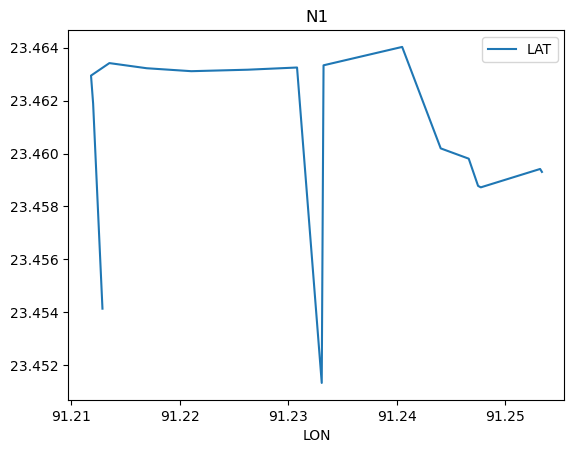

In [9]:
df_rd1.plot(x="LON", y="LAT", title="N1")

In [10]:
df_rd1.describe()

,LAT,LON
count,17.000000,17.000000
mean,23.460592,91.232036
std,0.003531,0.015264
min,23.451333,91.211806
25%,23.459306,91.216944
50%,23.461889,91.233083
75%,23.463222,91.246639
max,23.464028,91.253389


In [11]:
dist_dict = {}
# for index, data in df_rd1.iterrows():
#     print(index)
#     print(f"LRP: {data['LRP']}, LAT: {data['LAT']}, LON: {data['LON']}")
#     dist_dict[(data['LRP'],)]

for i in range(0, len(df_rd1) - 1, 1):
    point1 = df_rd1.iloc[i]
    point2 = df_rd1.iloc[i+1]
    coord1 = (point1.LAT, point1.LON)
    coord2 = (point2.LAT, point2.LON)
    distance = dist(coord1, coord2)
    dist_dict[(point1.LRP, point2.LRP)] = distance

print(dist_dict)    


{('LRPS', 'LRPSa'): 0.007797691530832279, ('LRPSa', 'LRP001'): 0.0010732528173727324, ('LRP001', 'LRP001a'): 0.0017589936469379268, ('LRP001a', 'LRP001b'): 0.0034492881425006883, ('LRP001b', 'LRP002'): 0.004112600931287203, ('LRP002', 'LRP002a'): 0.005194697558095177, ('LRP002a', 'LRP003'): 0.004556361514399489, ('LRP003', 'LRP003a'): 0.012132440468839463, ('LRP003a', 'LRP003b'): 0.012001156425941862, ('LRP003b', 'LRP004'): 0.007283586370055739, ('LRP004', 'LRP004a'): 0.005228435311837495, ('LRP004a', 'LRP005'): 0.002612493253571112, ('LRP005', 'LRP005a'): 0.0013408452744494666, ('LRP005a', 'LRP005b'): 0.0002561081021705381, ('LRP005b', 'LRP006'): 0.00551639252591364, ('LRP006', 'LRPE'): 0.00020032997779245848}


In [12]:
median_n1 = np.median(list(dist_dict.values()))
median_n1

0.004334481222843346

In [13]:
std_n1 = np.std(list(dist_dict.values()))
std_n1

0.0035825039546868386

In [31]:
outliers = []
for (LRP1, LRP2), distance in dist_dict.items():
    if distance > median_n1 + 0.8 * std_n1:
        outliers.append((LRP1, LRP2, distance))
print(len(outliers))
print("Outliers:", outliers)

4
Outliers: [('LRPS', 'LRPSa', 0.007797691530832279), ('LRP003', 'LRP003a', 0.012132440468839463), ('LRP003a', 'LRP003b', 0.012001156425941862), ('LRP003b', 'LRP004', 0.007283586370055739)]


In [ ]:
lrp_outliers = []
print(outliers)
if outliers[0][0] == 'LRPS':
    lrp1, lrp2, dist = outliers[0]
    lrp_outliers.append(lrp1)
    print(lrp_outliers)
    outliers = outliers[1:]
print(outliers)

for i in range(0, len(outliers), 2):
    lrp1, lrp2, dist = outliers[i]
    lrp2_2, lrp3, dist2 = outliers[i+1]
    if lrp2 == lrp2_2:
        print(f'De outlier is {lrp2}')
        lrp_outliers.append(lrp2)
    else:
        if abs(dist - dist2) < 0.5 * std_n1:
            print(f'De outlier is {lrp2} maar ook {lrp2_2} is een outlier')
            lrp_outliers.append(lrp2)
            lrp_outliers.append(lrp2_2)

[('LRPS', 'LRPSa', 0.007797691530832279), ('LRP003', 'LRP003a', 0.012132440468839463), ('LRP003a', 'LRP003b', 0.012001156425941862), ('LRP003b', 'LRP004', 0.007283586370055739)]
['LRPS']
[('LRP003', 'LRP003a', 0.012132440468839463), ('LRP003a', 'LRP003b', 0.012001156425941862), ('LRP003b', 'LRP004', 0.007283586370055739)]
De outlier is LRP003a


IndexError: list index out of range

In [38]:
# lrp_outliers
df_rd1_outliers = df_rd1[df_rd1["LRP"].isin(lrp_outliers)]
df_rd1_outliers

,road,LRP,LAT,LON
1348,N101,LRPS,23.454139,91.212861
1356,N101,LRP003a,23.451333,91.233083


In [47]:
def snap_point(lrp, index):
    max_index = df_rd1.index.max()
    print(max_index)

    if index == 0:
        n1_idx = index + 1
        n2_idx = index + 2
        mode = 'extrapolate_backward'

    elif index == max_index:
        n1_idx = index - 1
        n2_idx = index - 2
        mode = 'extrapolate_forward'

    else:
        n1_idx = index - 1
        n2_idx = index + 1
        mode = 'interpolate'

    if df_rd1.iloc[n1_idx]['LRP'] in lrp_outliers:
        # If n1 is bad, shift it further away by 1
        step = 1 if n1_idx > index else -1
        n1_idx += step 
    
    # Check Neighbor 2 (Only if still in bounds)
    if 0 <= n2_idx <= max_index and df_rd1.iloc[n2_idx]['LRP'] in lrp_outliers:
        step = 1 if n2_idx > index else -1
        n2_idx += step

    # Final Boundary Safety Check (if skipping pushed us off the map)
    if not (0 <= n1_idx <= max_index) or not (0 <= n2_idx <= max_index):
        print(f"Cannot fix Index {index}: Neighbors unavailable or invalid.")
        return

    p1 = df_rd1.iloc[n1_idx]
    p2 = df_rd1.iloc[n2_idx]
    curr_pt = df_rd1.iloc[index]

    if mode == 'interpolate':
        # Average of neighbors (The Sandwich Method)
        exp_lat = (p1['LAT'] + p2['LAT']) / 2.0
        exp_lon = (p1['LON'] + p2['LON']) / 2.0
        
    elif mode == 'extrapolate_backward':
        # Predict 0 using the slope of 2 -> 1
        # Logic: Expected = P1 + (P1 - P2)
        exp_lat = p1['LAT'] + (p1['LAT'] - p2['LAT'])
        exp_lon = p1['LON'] + (p1['LON'] - p2['LON'])
        
    elif mode == 'extrapolate_forward':
        # Predict End using the slope of (End-2) -> (End-1)
        # Logic: Expected = P1 + (P1 - P2)  (Since P1 is closer to target than P2)
        exp_lat = p1['LAT'] + (p1['LAT'] - p2['LAT'])
        exp_lon = p1['LON'] + (p1['LON'] - p2['LON'])

    # 4. Calculate Deviations (How far off is the current point?)
    # We use absolute difference

    lat_diff = abs(curr_pt['LAT'] - exp_lat)
    lon_diff = abs(curr_pt['LON'] - exp_lon)

    if lat_diff > lon_diff:
        print(f"Index {index}: Fixed LAT based on {mode}")
        print(f"Original LAT: {curr_pt['LAT']}, Expected LAT: {exp_lat}, Deviation: {lat_diff}")
        df_rd1_copy.at[index, 'LAT'] = exp_lat
        print(df_rd1_copy.at[index, 'LAT'])
    else:
        print(f"Index {index}: Fixed LON based on {mode}")
        df_rd1_copy.at[index, 'LON'] = exp_lon

df_rd1_copy = df_rd1.copy()

for outlier in lrp_outliers:
    row_pos_array = np.where(df_rd1['LRP'] == outlier)[0]
    if len(row_pos_array) > 0:
        row_pos = row_pos_array[0]
        
        # 2. Get the "Real" Index Label (1348, 1356) for your reference
        # We look up the label that sits at that integer position
        real_index = df_rd1.index[row_pos]
        
        print(f"LRP {outlier}: Row Pos {row_pos} | Original Index {real_index}")
        
        # IMPORTANT: Pass 'row_pos' (0), not 'real_index' (1348)
        # Your snap_point function uses .iloc, which expects 0, 1, 2...
        snap_point(df_rd1, real_index)

# df_rd1_copy.plot(x="LON", y="LAT", title="N1 Snapped")




LRP LRPS: Row Pos 0 | Original Index 1348
1364


IndexError: single positional indexer is out-of-bounds

      road      LRP        LAT        LON
1348  N101     LRPS  23.454139  91.212861
1349  N101    LRPSa  23.461889  91.212000
1350  N101   LRP001  23.462944  91.211806
1351  N101  LRP001a  23.463417  91.213500
1352  N101  LRP001b  23.463222  91.216944
1353  N101   LRP002  23.463111  91.221055
1354  N101  LRP002a  23.463167  91.226249
1355  N101   LRP003  23.463250  91.230805
1356  N101  LRP003a  23.451333  91.233083
1357  N101  LRP003b  23.463333  91.233249
1358  N101   LRP004  23.464028  91.240500
1359  N101  LRP004a  23.460194  91.244055
1360  N101   LRP005  23.459806  91.246639
1361  N101  LRP005a  23.458778  91.247500
1362  N101  LRP005b  23.458722  91.247750
1363  N101   LRP006  23.459417  91.253222
1364  N101     LRPE  23.459306  91.253389
0      NaN      NaN  23.460833        NaN
8      NaN      NaN  23.463292        NaN
      road      LRP        LAT        LON
1348  N101     LRPS  23.454139  91.212861
1349  N101    LRPSa  23.461889  91.212000
1350  N101   LRP001  23.462944  91

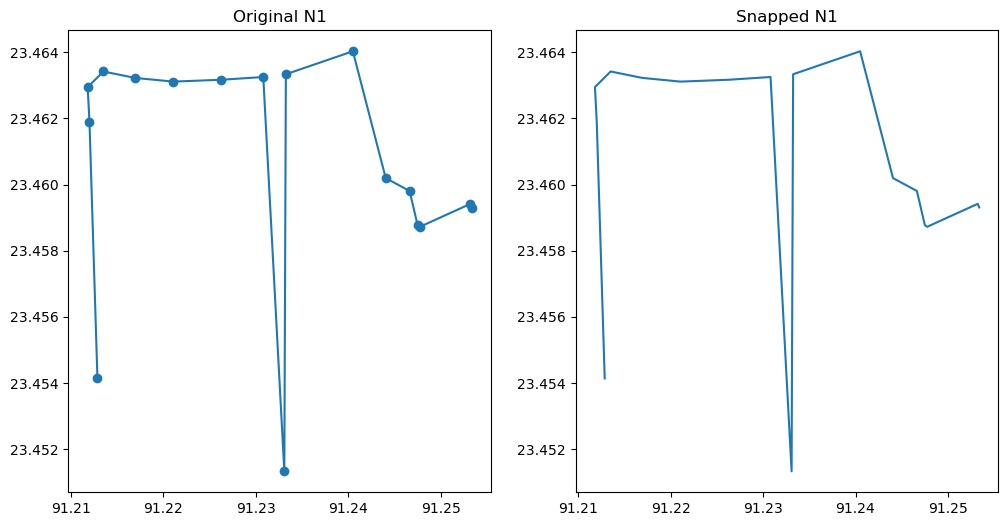

In [ ]:
f, axes = plt.subplots(1,2, figsize=(12, 6))
axes.flatten()
axes[0].plot(df_rd1['LON'], df_rd1['LAT'], marker='o', label='Original N1')
axes[0].set_title('Original N1')
axes[1].plot(df_rd1_copy['LON'], df_rd1_copy['LAT'],  label='Snapped N1')
axes[1].set_title('Snapped N1')

print(df_rd1_copy)
print(df_rd1)